In [2]:
"""
EnergyPlus Model Calibration with HVAC Parameters (Top 10 Zones Only)
====================================================================
Optimizes six parameters:
    1. Internal gains multiplier
    2. Infiltration multiplier
    3. VAV terminal minimum airflow multiplier
    4. Reheat coil capacity multiplier
    5. Minimum outdoor air flow multiplier
    6. Supply Air Temperature offset (°C)

Uses only the 10 best zones (lowest baseline RMSE) for calibration.
Outputs saved in: calibration_10
"""

import os
import subprocess
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from scipy.optimize import differential_evolution
from eppy.modeleditor import IDF

# -----------------------------
# USER CONFIGURATION
# -----------------------------
EP_PATH       = r"C:\EnergyPlusV25-1-0"
EPLUS_EXE     = os.path.join(EP_PATH, "energyplus.exe")
IDD_PATH      = os.path.join(EP_PATH, "Energy+.idd")
WEATHER_FILE  = os.path.join(EP_PATH, "WeatherData", "USA_CA_San.Francisco.Intl.AP.724940_TMY3.epw")
IDF_TEMPLATE  = "model.idf"
SYNTHETIC_CSV = "data3.csv"
OUTDIR        = "calibration_10_newdata"   # <--- NEW OUTPUT FOLDER

TOP10_ZONES = [
    "PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "CORE_MID:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_4:Zone Mean Air Temperature [C](Hourly)",
    "CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_2:Zone Mean Air Temperature [C](Hourly)"
]

# -----------------------------
# LOAD SYNTHETIC DATA
# -----------------------------
df_synth = pd.read_csv(SYNTHETIC_CSV)
if "Date/Time" not in df_synth.columns:
    raise RuntimeError("Synthetic CSV must have a 'Date/Time' column aligned to EnergyPlus format.")
df_synth["Date/Time"] = df_synth["Date/Time"].astype(str).str.strip()

# -----------------------------
# INITIALIZE EPPY
# -----------------------------
IDF.setiddname(IDD_PATH)

# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def safe_float(x):
    try:
        return float(x)
    except:
        return None

def clamp(val, lo, hi):
    try:
        v = float(val)
        return max(lo, min(hi, v))
    except:
        return val

def is_autosize_or_blank(x):
    if x is None:
        return True
    s = str(x).strip().lower()
    return s in ["", "autosize"]

def run_eplus(idf_file, outdir=OUTDIR):
    if not os.path.isdir(outdir):
        os.makedirs(outdir, exist_ok=True)
    cmd = [
        EPLUS_EXE,
        "-w", WEATHER_FILE,
        "-d", outdir,
        "-r", idf_file
    ]
    subprocess.run(cmd, check=True)
    return os.path.join(outdir, "eplusout.csv")

def compute_rmse(sim_csv):
    """Compute RMSE only for top 10 selected zones"""
    df_sim = pd.read_csv(sim_csv)
    df_sim["Date/Time"] = df_sim["Date/Time"].astype(str).str.strip()
    df_synth["Date/Time"] = df_synth["Date/Time"].astype(str).str.strip()

    # Use only top 10 zones
    common_cols = [c for c in TOP10_ZONES if c in df_sim.columns and c in df_synth.columns]

    df_a = df_sim[["Date/Time"] + common_cols]
    df_b = df_synth[["Date/Time"] + common_cols]
    df_merged = pd.merge(df_a, df_b, on="Date/Time", suffixes=("_sim", "_syn"))

    total = 0.0
    for col in common_cols:
        s = df_merged[f"{col}_sim"].astype(float).to_numpy()
        y = df_merged[f"{col}_syn"].astype(float).to_numpy()
        rmse = np.sqrt(mean_squared_error(y, s))
        total += rmse
    return total / len(common_cols)

# -----------------------------
# MODIFY PARAMETERS
# -----------------------------
def modify_internal_infiltration(idf, internal_mult=1.0, infil_mult=1.0):
    if "PEOPLE" in idf.idfobjects:
        for obj in idf.idfobjects["PEOPLE"]:
            if hasattr(obj, "Number_of_People") and not is_autosize_or_blank(obj.Number_of_People):
                v = safe_float(obj.Number_of_People)
                if v is not None:
                    obj.Number_of_People = v * internal_mult

    if "LIGHTS" in idf.idfobjects:
        for obj in idf.idfobjects["LIGHTS"]:
            if hasattr(obj, "Watts_per_Zone_Floor_Area") and not is_autosize_or_blank(obj.Watts_per_Zone_Floor_Area):
                v = safe_float(obj.Watts_per_Zone_Floor_Area)
                if v is not None:
                    obj.Watts_per_Zone_Floor_Area = v * internal_mult

    if "ELECTRICEQUIPMENT" in idf.idfobjects:
        for obj in idf.idfobjects["ELECTRICEQUIPMENT"]:
            if hasattr(obj, "Design_Level") and not is_autosize_or_blank(obj.Design_Level):
                v = safe_float(obj.Design_Level)
                if v is not None:
                    obj.Design_Level = v * internal_mult

    key = "ZONEINFILTRATION:DESIGNFLOWRATE"
    if key in idf.idfobjects:
        for obj in idf.idfobjects[key]:
            if hasattr(obj, "Design_Flow_Rate") and not is_autosize_or_blank(obj.Design_Flow_Rate):
                v = safe_float(obj.Design_Flow_Rate)
                if v is not None:
                    obj.Design_Flow_Rate = max(0.0, v * infil_mult)

def modify_hvac(idf, vav_min_flow_mult=1.0, reheat_cap_mult=1.0, oa_min_flow_mult=1.0, sat_offset_c=0.0):
    key = "AIRTERMINAL:SINGLEDUCT:VAV:REHEAT"
    if key in idf.idfobjects:
        for at in idf.idfobjects[key]:
            if hasattr(at, "Zone_Minimum_Air_Flow_Fraction") and not is_autosize_or_blank(at.Zone_Minimum_Air_Flow_Fraction):
                v = safe_float(at.Zone_Minimum_Air_Flow_Fraction)
                if v is not None:
                    at.Zone_Minimum_Air_Flow_Fraction = clamp(v * vav_min_flow_mult, 0.1, 0.8)

    for coil_type in ["COIL:HEATING:ELECTRIC", "COIL:HEATING:FUEL"]:
        if coil_type in idf.idfobjects:
            for c in idf.idfobjects[coil_type]:
                if hasattr(c, "Nominal_Capacity") and not is_autosize_or_blank(c.Nominal_Capacity):
                    v = safe_float(c.Nominal_Capacity)
                    if v is not None:
                        c.Nominal_Capacity = max(0.0, v * reheat_cap_mult)

    key = "CONTROLLER:OUTDOORAIR"
    if key in idf.idfobjects:
        for ctrl in idf.idfobjects[key]:
            if hasattr(ctrl, "Minimum_Outdoor_Air_Flow_Rate") and not is_autosize_or_blank(ctrl.Minimum_Outdoor_Air_Flow_Rate):
                v = safe_float(ctrl.Minimum_Outdoor_Air_Flow_Rate)
                if v is not None:
                    ctrl.Minimum_Outdoor_Air_Flow_Rate = max(0.0, v * oa_min_flow_mult)

# -----------------------------
# BUILD MODIFIED IDF
# -----------------------------
def build_modified_idf(out_idf,
                       internal_mult=1.0, infil_mult=1.0,
                       vav_min_flow_mult=1.0, reheat_cap_mult=1.0,
                       oa_min_flow_mult=1.0, sat_offset_c=0.0):
    idf = IDF(IDF_TEMPLATE)
    modify_internal_infiltration(idf, internal_mult, infil_mult)
    modify_hvac(idf, vav_min_flow_mult, reheat_cap_mult, oa_min_flow_mult, sat_offset_c)
    idf.saveas(out_idf)
    return out_idf

# -----------------------------
# OBJECTIVE FUNCTION WITH LOGGING
# -----------------------------
iteration_counter = {"count": 0}
def objective(params):
    iteration_counter["count"] += 1
    (internal_mult,
     infil_mult,
     vav_min_flow_mult,
     reheat_cap_mult,
     oa_min_flow_mult,
     sat_offset_c) = params

    print(f"\n🔄 Iteration {iteration_counter['count']}")
    print(f"   Params: Internal={internal_mult:.3f}, Infil={infil_mult:.3f}, "
          f"VAV={vav_min_flow_mult:.3f}, Reheat={reheat_cap_mult:.3f}, "
          f"OA={oa_min_flow_mult:.3f}, SAT_Offset={sat_offset_c:.3f}")

    mod_path = "model_cal_10_newdata.idf"
    build_modified_idf(mod_path,
                       internal_mult=internal_mult,
                       infil_mult=infil_mult,
                       vav_min_flow_mult=vav_min_flow_mult,
                       reheat_cap_mult=reheat_cap_mult,
                       oa_min_flow_mult=oa_min_flow_mult,
                       sat_offset_c=sat_offset_c)

    sim_csv = run_eplus(mod_path, OUTDIR)
    rmse = compute_rmse(sim_csv)
    print(f"   RMSE (10 zones) = {rmse:.3f} °C")
    return rmse

# -----------------------------
# CALIBRATION
# -----------------------------
bounds = [
    (0.6, 1.1),   # internal gains
    (0.5, 1.5),   # infiltration
    (0.2, 0.6),   # VAV min flow
    (0.8, 1.2),   # reheat coil
    (0.5, 1.5),   # outdoor air min
    (-1.0, 1.0),  # SAT offset
]

result = differential_evolution(
    objective,
    bounds,
    maxiter=5,  # increase later if needed
    tol=1e-2,
    polish=False,
    disp=True
)

best = result.x
print("\n✅ Best Parameters Found (10 zones):")
print(f"   Internal Gains Mult = {best[0]:.3f}")
print(f"   Infiltration Mult   = {best[1]:.3f}")
print(f"   VAV Min Flow Mult   = {best[2]:.3f}")
print(f"   Reheat Cap. Mult    = {best[3]:.3f}")
print(f"   OA Min Flow Mult    = {best[4]:.3f}")
print(f"   SAT Offset (°C)     = {best[5]:.3f}")
print(f"   Final RMSE (10 zones) = {result.fun:.3f} °C")



🔄 Iteration 1
   Params: Internal=0.971, Infil=0.917, VAV=0.517, Reheat=1.028, OA=1.192, SAT_Offset=-0.467
   RMSE (10 zones) = 0.386 °C

🔄 Iteration 2
   Params: Internal=1.033, Infil=1.390, VAV=0.524, Reheat=1.099, OA=0.619, SAT_Offset=-0.301
   RMSE (10 zones) = 0.401 °C

🔄 Iteration 3
   Params: Internal=0.949, Infil=1.024, VAV=0.416, Reheat=1.117, OA=0.728, SAT_Offset=0.655
   RMSE (10 zones) = 0.386 °C

🔄 Iteration 4
   Params: Internal=0.928, Infil=1.344, VAV=0.405, Reheat=1.159, OA=0.770, SAT_Offset=-0.098
   RMSE (10 zones) = 0.393 °C

🔄 Iteration 5
   Params: Internal=0.613, Infil=0.703, VAV=0.576, Reheat=1.184, OA=1.111, SAT_Offset=-0.545
   RMSE (10 zones) = 0.711 °C

🔄 Iteration 6
   Params: Internal=0.785, Infil=1.471, VAV=0.329, Reheat=0.993, OA=1.123, SAT_Offset=-0.455
   RMSE (10 zones) = 0.496 °C

🔄 Iteration 7
   Params: Internal=0.651, Infil=1.235, VAV=0.505, Reheat=1.047, OA=0.650, SAT_Offset=0.856
   RMSE (10 zones) = 0.666 °C

🔄 Iteration 8
   Params: Internal=0

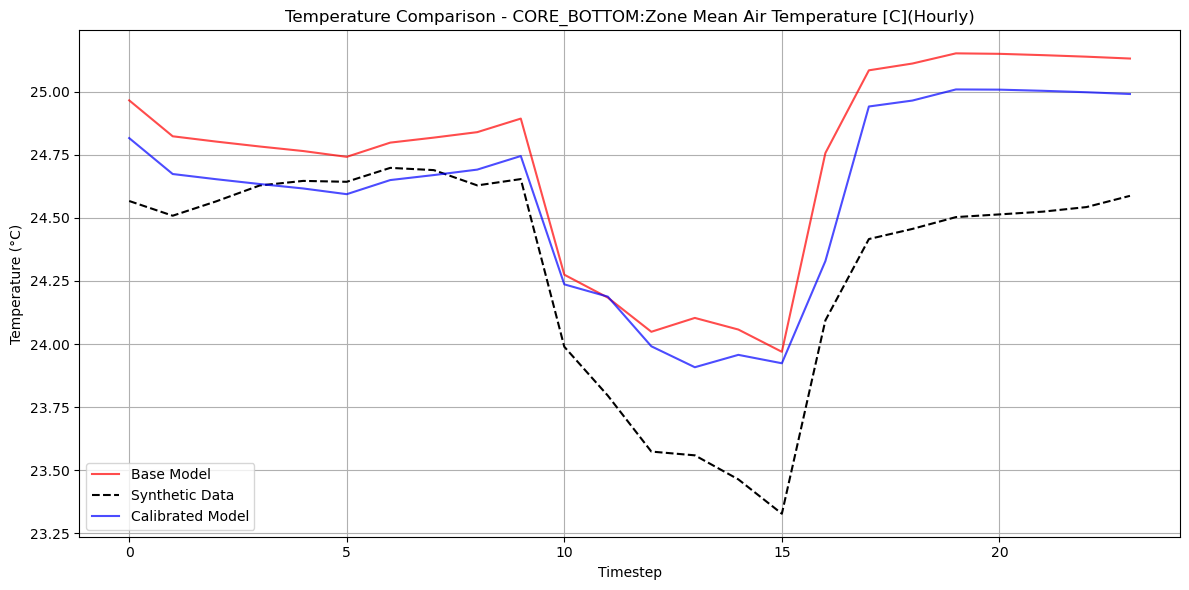

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths (adjust if needed)
synthetic_csv   = "data3.csv"                          # synthetic dataset
base_csv        = "model.csv"    # base model output
calibrated_csv  = "calibration_10_newdata/eplusout.csv"   # calibrated model output

# Choose one zone to plot (can change to any of the 18 zones)
zone = "CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)"

# Load all CSVs
df_synth = pd.read_csv(synthetic_csv)
df_base  = pd.read_csv(base_csv)
df_cal   = pd.read_csv(calibrated_csv)

# Strip spaces in Date/Time for alignment
for df in [df_synth, df_base, df_cal]:
    df["Date/Time"] = df["Date/Time"].astype(str).str.strip()

# Merge them on Date/Time
df_plot = df_base[["Date/Time", zone]].merge(
    df_synth[["Date/Time", zone]], on="Date/Time", suffixes=("_base", "_synth")
).merge(
    df_cal[["Date/Time", zone]], on="Date/Time"
)
df_plot.rename(columns={zone: f"{zone}_calibrated"}, inplace=True)

# Convert Date/Time to numeric index for plotting
df_plot["TimeIndex"] = range(len(df_plot))

# Plot
plt.figure(figsize=(12,6))
plt.plot(df_plot["TimeIndex"], df_plot[f"{zone}_base"], label="Base Model", color="red", alpha=0.7)
plt.plot(df_plot["TimeIndex"], df_plot[f"{zone}_synth"], label="Synthetic Data", color="black", linestyle="--")
plt.plot(df_plot["TimeIndex"], df_plot[f"{zone}_calibrated"], label="Calibrated Model", color="blue", alpha=0.7)

plt.title(f"Temperature Comparison - {zone}")
plt.xlabel("Timestep")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# -----------------------------
# File paths
# -----------------------------
eplus_output = "calibration_10_newdata/eplusout.csv"   # Base IDF simulation output
synthetic_file = "data3.csv"                       # Synthetic dataset

# -----------------------------
# Load CSVs
# -----------------------------
df_sim = pd.read_csv(eplus_output)
df_synth = pd.read_csv(synthetic_file)

# Strip spaces in Date/Time
df_sim["Date/Time"] = df_sim["Date/Time"].astype(str).str.strip()
df_synth["Date/Time"] = df_synth["Date/Time"].astype(str).str.strip()

# Merge data on Date/Time
common_cols = [c for c in df_sim.columns if "Zone Mean Air Temperature" in c and c in df_synth.columns]
df_merged = pd.merge(
    df_sim[["Date/Time"] + common_cols],
    df_synth[["Date/Time"] + common_cols],
    on="Date/Time",
    suffixes=("_sim", "_syn")
)

# -----------------------------
# Calculate RMSE per zone
# -----------------------------
rmse_results = []
for col in common_cols:
    sim_values = df_merged[f"{col}_sim"].astype(float).to_numpy()
    synth_values = df_merged[f"{col}_syn"].astype(float).to_numpy()
    rmse = np.sqrt(mean_squared_error(synth_values, sim_values))
    rmse_results.append((col, rmse))

# Create DataFrame for display
df_rmse = pd.DataFrame(rmse_results, columns=["Zone", "RMSE (°C)"])
df_rmse = df_rmse.sort_values(by="RMSE (°C)").reset_index(drop=True)

# -----------------------------
# Display results
# -----------------------------
print("\n✅ RMSE per Zone:")
print(df_rmse.to_string(index=False))



✅ RMSE per Zone:
                                                     Zone  RMSE (°C)
 PERIMETER_MID_ZN_1:Zone Mean Air Temperature [C](Hourly)   0.230315
 PERIMETER_BOT_ZN_4:Zone Mean Air Temperature [C](Hourly)   0.237111
 PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)   0.259397
           CORE_MID:Zone Mean Air Temperature [C](Hourly)   0.306558
        CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)   0.348307
 PERIMETER_TOP_ZN_1:Zone Mean Air Temperature [C](Hourly)   0.422045
 PERIMETER_BOT_ZN_1:Zone Mean Air Temperature [C](Hourly)   0.503878
 PERIMETER_MID_ZN_2:Zone Mean Air Temperature [C](Hourly)   0.505420
 PERIMETER_BOT_ZN_2:Zone Mean Air Temperature [C](Hourly)   0.513722
 PERIMETER_TOP_ZN_2:Zone Mean Air Temperature [C](Hourly)   0.539459
           CORE_TOP:Zone Mean Air Temperature [C](Hourly)   0.773502
 PERIMETER_TOP_ZN_3:Zone Mean Air Temperature [C](Hourly)   0.792393
  FIRSTFLOOR_PLENUM:Zone Mean Air Temperature [C](Hourly)   0.796888
    TOPFLOOR_PLE

In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# -----------------------------
# File paths
# -----------------------------
eplus_output = "calibration_10_newdata/eplusout.csv"   # Base IDF simulation output
synthetic_file = "data3.csv"                  # Synthetic dataset

# -----------------------------
# Load CSVs
# -----------------------------
df_sim = pd.read_csv(eplus_output)
df_synth = pd.read_csv(synthetic_file)

# Strip spaces in Date/Time
df_sim["Date/Time"] = df_sim["Date/Time"].astype(str).str.strip()
df_synth["Date/Time"] = df_synth["Date/Time"].astype(str).str.strip()

# Merge data on Date/Time
common_cols = [c for c in df_sim.columns if "Zone Mean Air Temperature" in c and c in df_synth.columns]
df_merged = pd.merge(
    df_sim[["Date/Time"] + common_cols],
    df_synth[["Date/Time"] + common_cols],
    on="Date/Time",
    suffixes=("_sim", "_syn")
)

# -----------------------------
# Calculate RMSE per zone
# -----------------------------
rmse_results = []
for col in common_cols:
    sim_values = df_merged[f"{col}_sim"].astype(float).to_numpy()
    synth_values = df_merged[f"{col}_syn"].astype(float).to_numpy()
    rmse = np.sqrt(mean_squared_error(synth_values, sim_values))
    rmse_results.append((col, rmse))

# Create DataFrame for display
df_rmse = pd.DataFrame(rmse_results, columns=["Zone", "RMSE (°C)"])
df_rmse = df_rmse.sort_values(by="RMSE (°C)").reset_index(drop=True)

# -----------------------------
# Add average RMSE
# -----------------------------
avg_rmse = df_rmse["RMSE (°C)"].mean()
df_rmse.loc[len(df_rmse)] = ["AVERAGE", avg_rmse]

# -----------------------------
# Display results
# -----------------------------
print("\n✅ RMSE per Zone:")
print(df_rmse.to_string(index=False))



✅ RMSE per Zone:
                                                     Zone  RMSE (°C)
 PERIMETER_MID_ZN_1:Zone Mean Air Temperature [C](Hourly)   0.230315
 PERIMETER_BOT_ZN_4:Zone Mean Air Temperature [C](Hourly)   0.237111
 PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)   0.259397
           CORE_MID:Zone Mean Air Temperature [C](Hourly)   0.306558
        CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)   0.348307
 PERIMETER_TOP_ZN_1:Zone Mean Air Temperature [C](Hourly)   0.422045
 PERIMETER_BOT_ZN_1:Zone Mean Air Temperature [C](Hourly)   0.503878
 PERIMETER_MID_ZN_2:Zone Mean Air Temperature [C](Hourly)   0.505420
 PERIMETER_BOT_ZN_2:Zone Mean Air Temperature [C](Hourly)   0.513722
 PERIMETER_TOP_ZN_2:Zone Mean Air Temperature [C](Hourly)   0.539459
           CORE_TOP:Zone Mean Air Temperature [C](Hourly)   0.773502
 PERIMETER_TOP_ZN_3:Zone Mean Air Temperature [C](Hourly)   0.792393
  FIRSTFLOOR_PLENUM:Zone Mean Air Temperature [C](Hourly)   0.796888
    TOPFLOOR_PLE

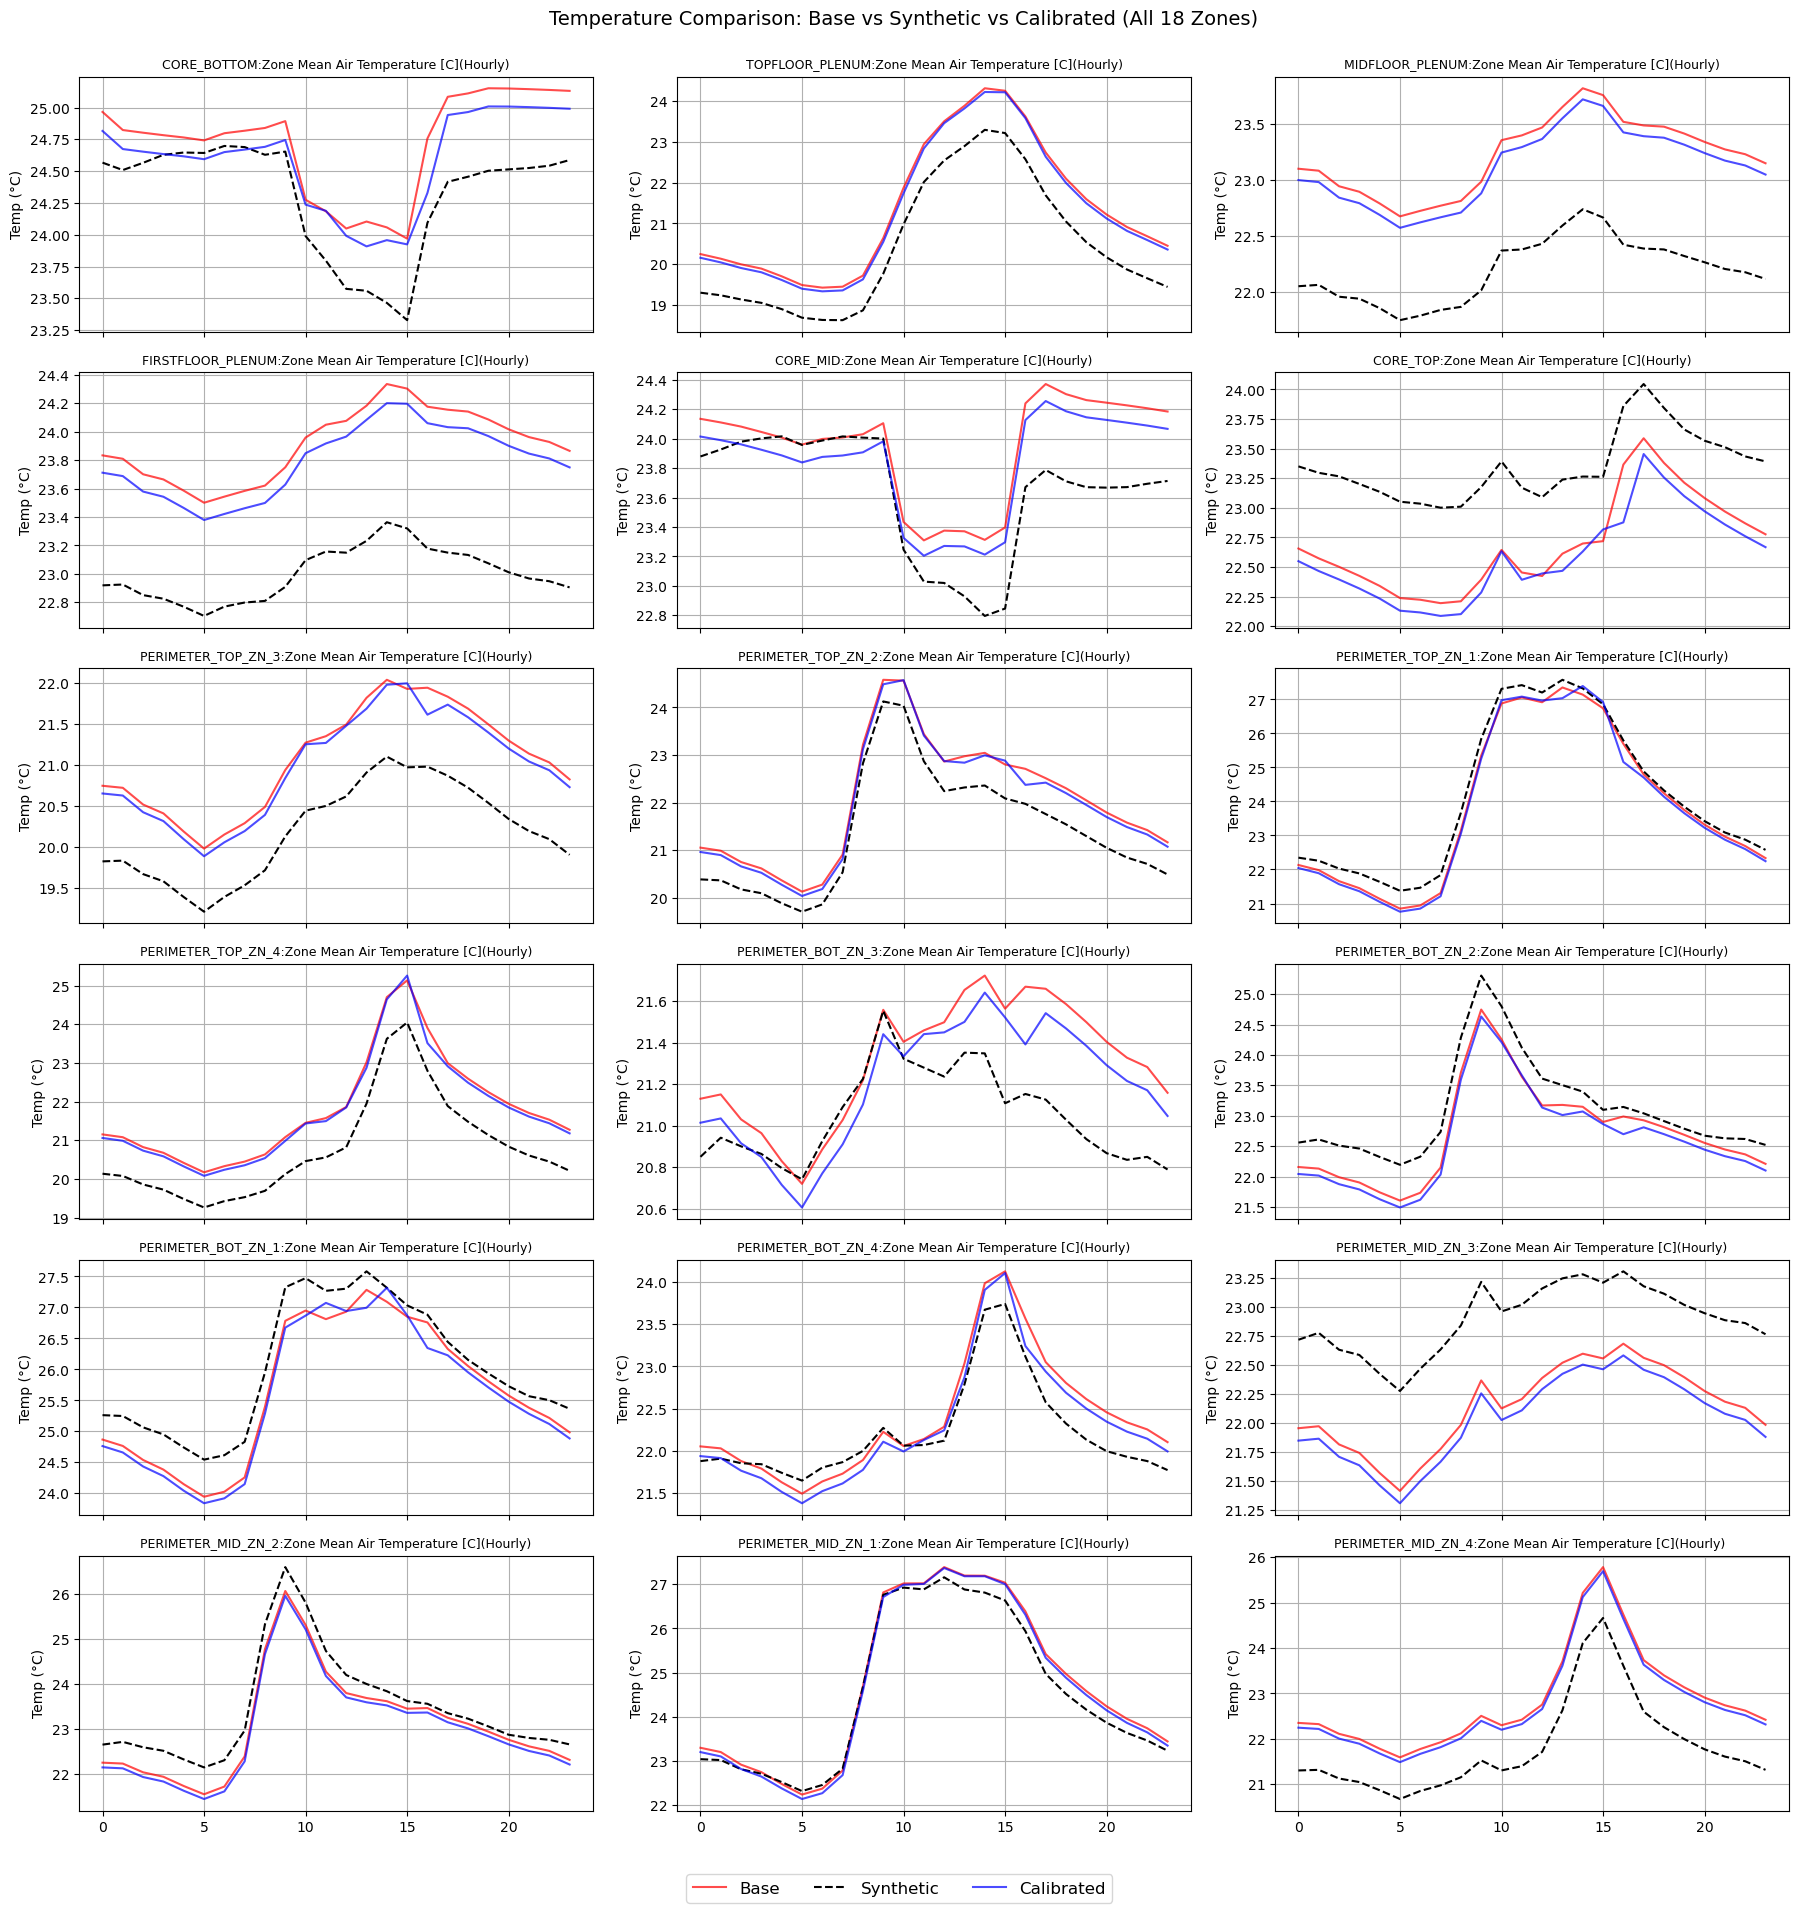

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths (adjust if needed)
synthetic_csv   = "data3.csv"                          # synthetic dataset
base_csv        = "model.csv"    # base model output
calibrated_csv  = "calibration_10_newdata/eplusout.csv"   # calibrated model output

# Load all CSVs
df_synth = pd.read_csv(synthetic_csv)
df_base  = pd.read_csv(base_csv)
df_cal   = pd.read_csv(calibrated_csv)

# Clean Date/Time
for df in [df_synth, df_base, df_cal]:
    df["Date/Time"] = df["Date/Time"].astype(str).str.strip()

# Identify zone columns
zone_cols = [c for c in df_base.columns if "Zone Mean Air Temperature" in c]

# Merge base, synth, and calibrated on Date/Time
df_merged = df_base[["Date/Time"] + zone_cols].merge(
    df_synth[["Date/Time"] + zone_cols], on="Date/Time", suffixes=("_base", "_synth")
).merge(
    df_cal[["Date/Time"] + zone_cols], on="Date/Time"
)

# Rename calibrated columns
rename_map = {c: c + "_cal" for c in zone_cols}
df_merged.rename(columns=rename_map, inplace=True)

# Create subplot grid
fig, axes = plt.subplots(6, 3, figsize=(18, 20), sharex=True)
axes = axes.flatten()

# Plot each zone
for i, zone in enumerate(zone_cols):
    ax = axes[i]
    ax.plot(df_merged.index, df_merged[f"{zone}_base"], label="Base", color="red", alpha=0.7)
    ax.plot(df_merged.index, df_merged[f"{zone}_synth"], label="Synthetic", color="black", linestyle="--")
    ax.plot(df_merged.index, df_merged[f"{zone}_cal"], label="Calibrated", color="blue", alpha=0.7)
    ax.set_title(zone, fontsize=9)
    ax.set_ylabel("Temp (°C)")
    ax.grid(True)
    if i >= len(zone_cols) - 1:
        break

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=12)

plt.suptitle("Temperature Comparison: Base vs Synthetic vs Calibrated (All 18 Zones)", fontsize=14, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


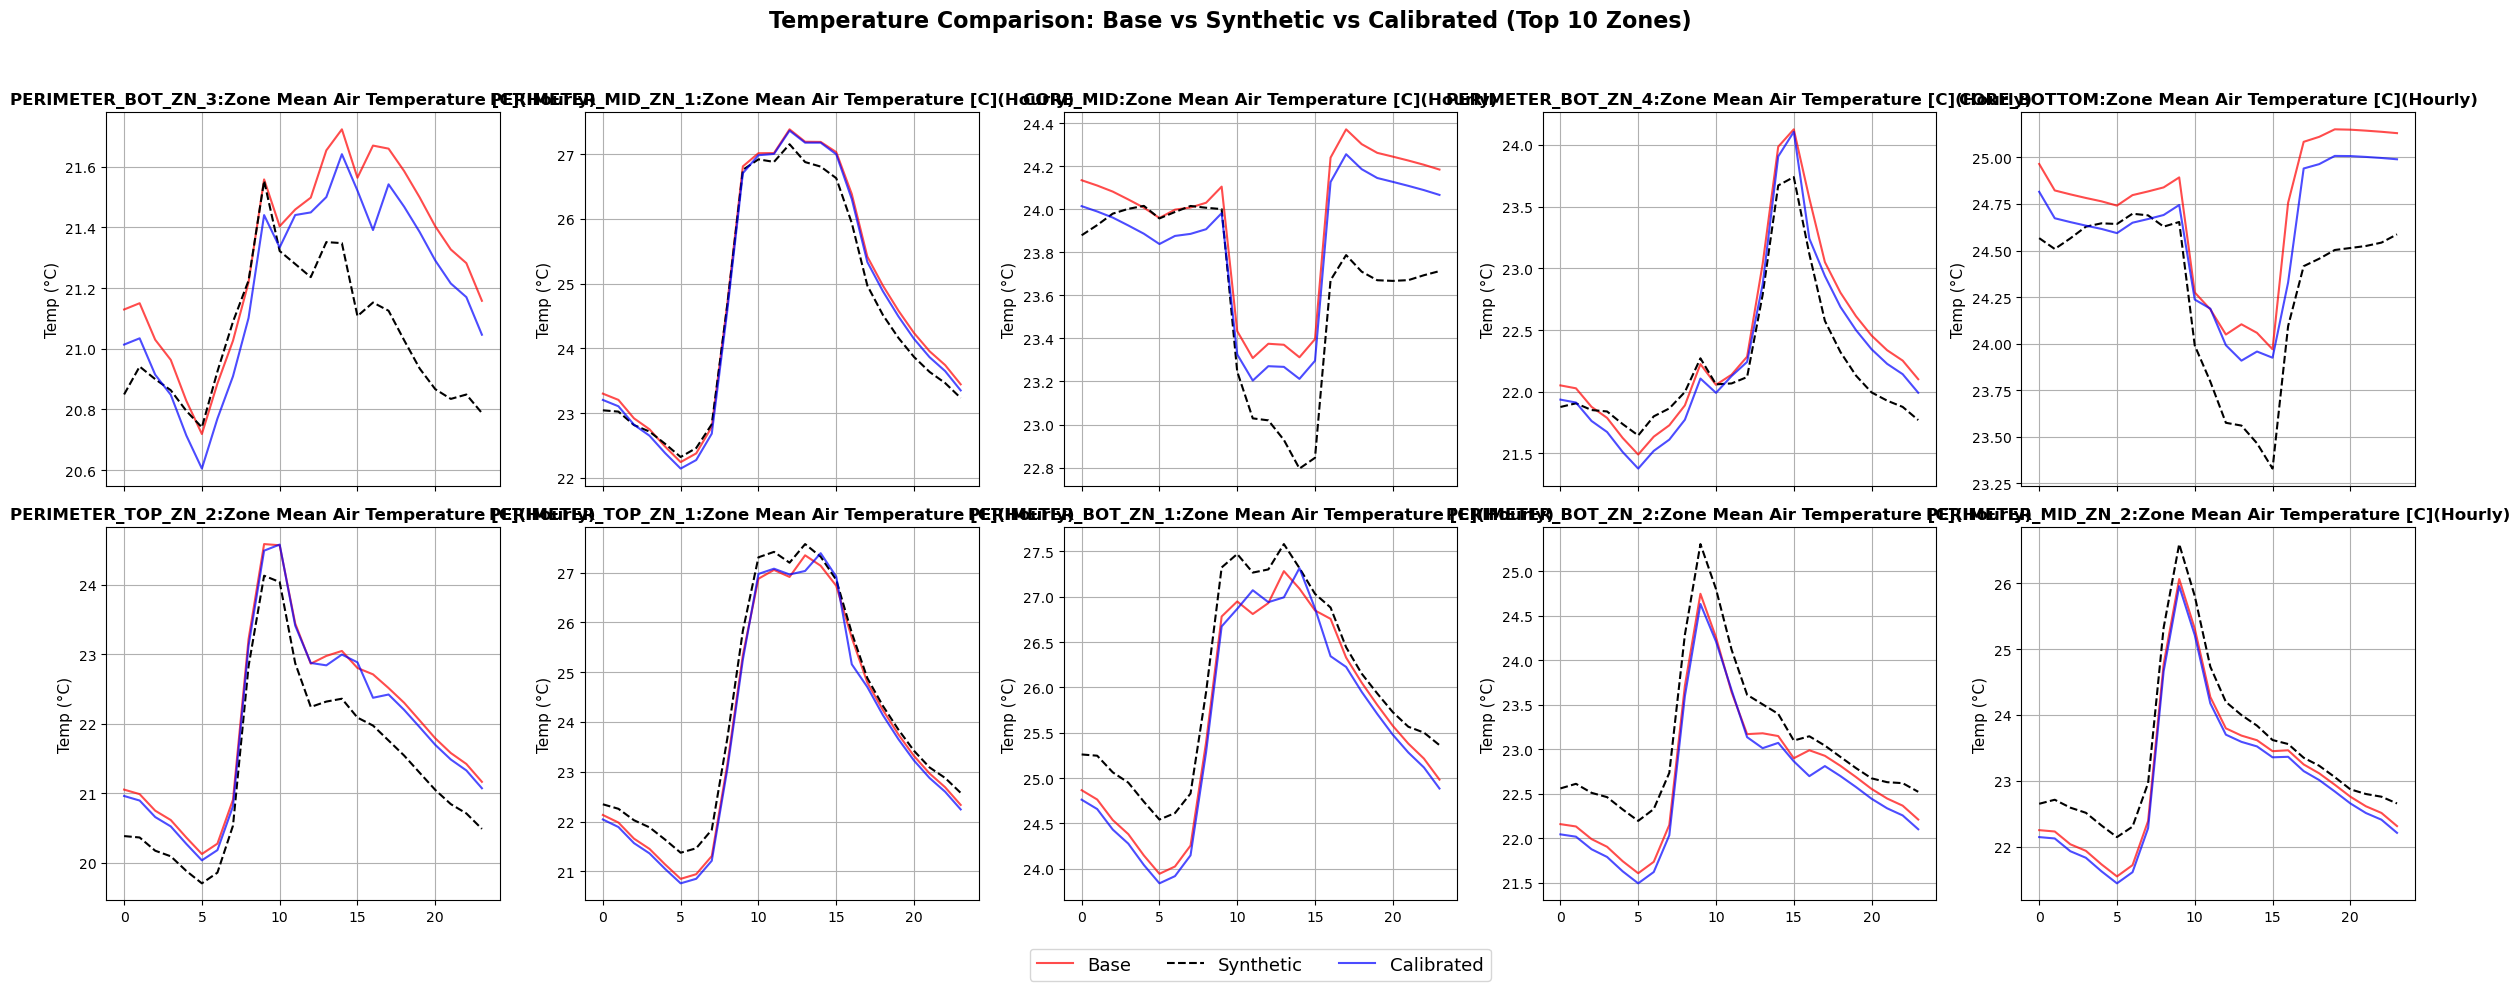

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# File paths (adjust if needed)
# -----------------------------
synthetic_csv   = "data3.csv"                          
base_csv        = "model.csv"    
calibrated_csv  = "calibration_10_newdata/eplusout.csv"

# -----------------------------
# Load all CSVs
# -----------------------------
df_synth = pd.read_csv(synthetic_csv)
df_base  = pd.read_csv(base_csv)
df_cal   = pd.read_csv(calibrated_csv)

# Clean Date/Time
for df in [df_synth, df_base, df_cal]:
    df["Date/Time"] = df["Date/Time"].astype(str).str.strip()

# -----------------------------
# Top 10 zones of interest
# -----------------------------
TOP10_ZONES = [
    "PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "CORE_MID:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_4:Zone Mean Air Temperature [C](Hourly)",
    "CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_2:Zone Mean Air Temperature [C](Hourly)"
]

# Keep only available zones
zone_cols = [z for z in TOP10_ZONES if z in df_base.columns]

# -----------------------------
# Merge base, synth, and calibrated on Date/Time
# -----------------------------
df_merged = df_base[["Date/Time"] + zone_cols].merge(
    df_synth[["Date/Time"] + zone_cols], on="Date/Time", suffixes=("_base", "_synth")
).merge(
    df_cal[["Date/Time"] + zone_cols], on="Date/Time"
)

# Rename calibrated columns
rename_map = {c: c + "_cal" for c in zone_cols}
df_merged.rename(columns=rename_map, inplace=True)

# -----------------------------
# Plotting only the top 10 zones (2 rows × 5 columns)
# -----------------------------
fig, axes = plt.subplots(2, 5, figsize=(24, 10), sharex=True)  # 2 rows × 5 cols
axes = axes.flatten()

for i, zone in enumerate(zone_cols):
    ax = axes[i]
    ax.plot(df_merged.index, df_merged[f"{zone}_base"], label="Base", color="red", alpha=0.7)
    ax.plot(df_merged.index, df_merged[f"{zone}_synth"], label="Synthetic", color="black", linestyle="--")
    ax.plot(df_merged.index, df_merged[f"{zone}_cal"], label="Calibrated", color="blue", alpha=0.7)
    ax.set_title(zone, fontsize=12, fontweight="bold")   # bigger title
    ax.set_ylabel("Temp (°C)", fontsize=11)
    ax.tick_params(axis="both", which="major", labelsize=10)  # larger tick labels
    ax.grid(True)

# Hide unused subplots if fewer than 10 zones are found
for j in range(len(zone_cols), len(axes)):
    fig.delaxes(axes[j])

# Shared legend (bigger font)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=13)

plt.suptitle("Temperature Comparison: Base vs Synthetic vs Calibrated (Top 10 Zones)", 
             fontsize=16, fontweight="bold", y=0.98)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# -----------------------------
# Save and show
# -----------------------------
plt.savefig("temperature_comparison_top10.png", dpi=300, bbox_inches="tight")   # PNG
plt.show()


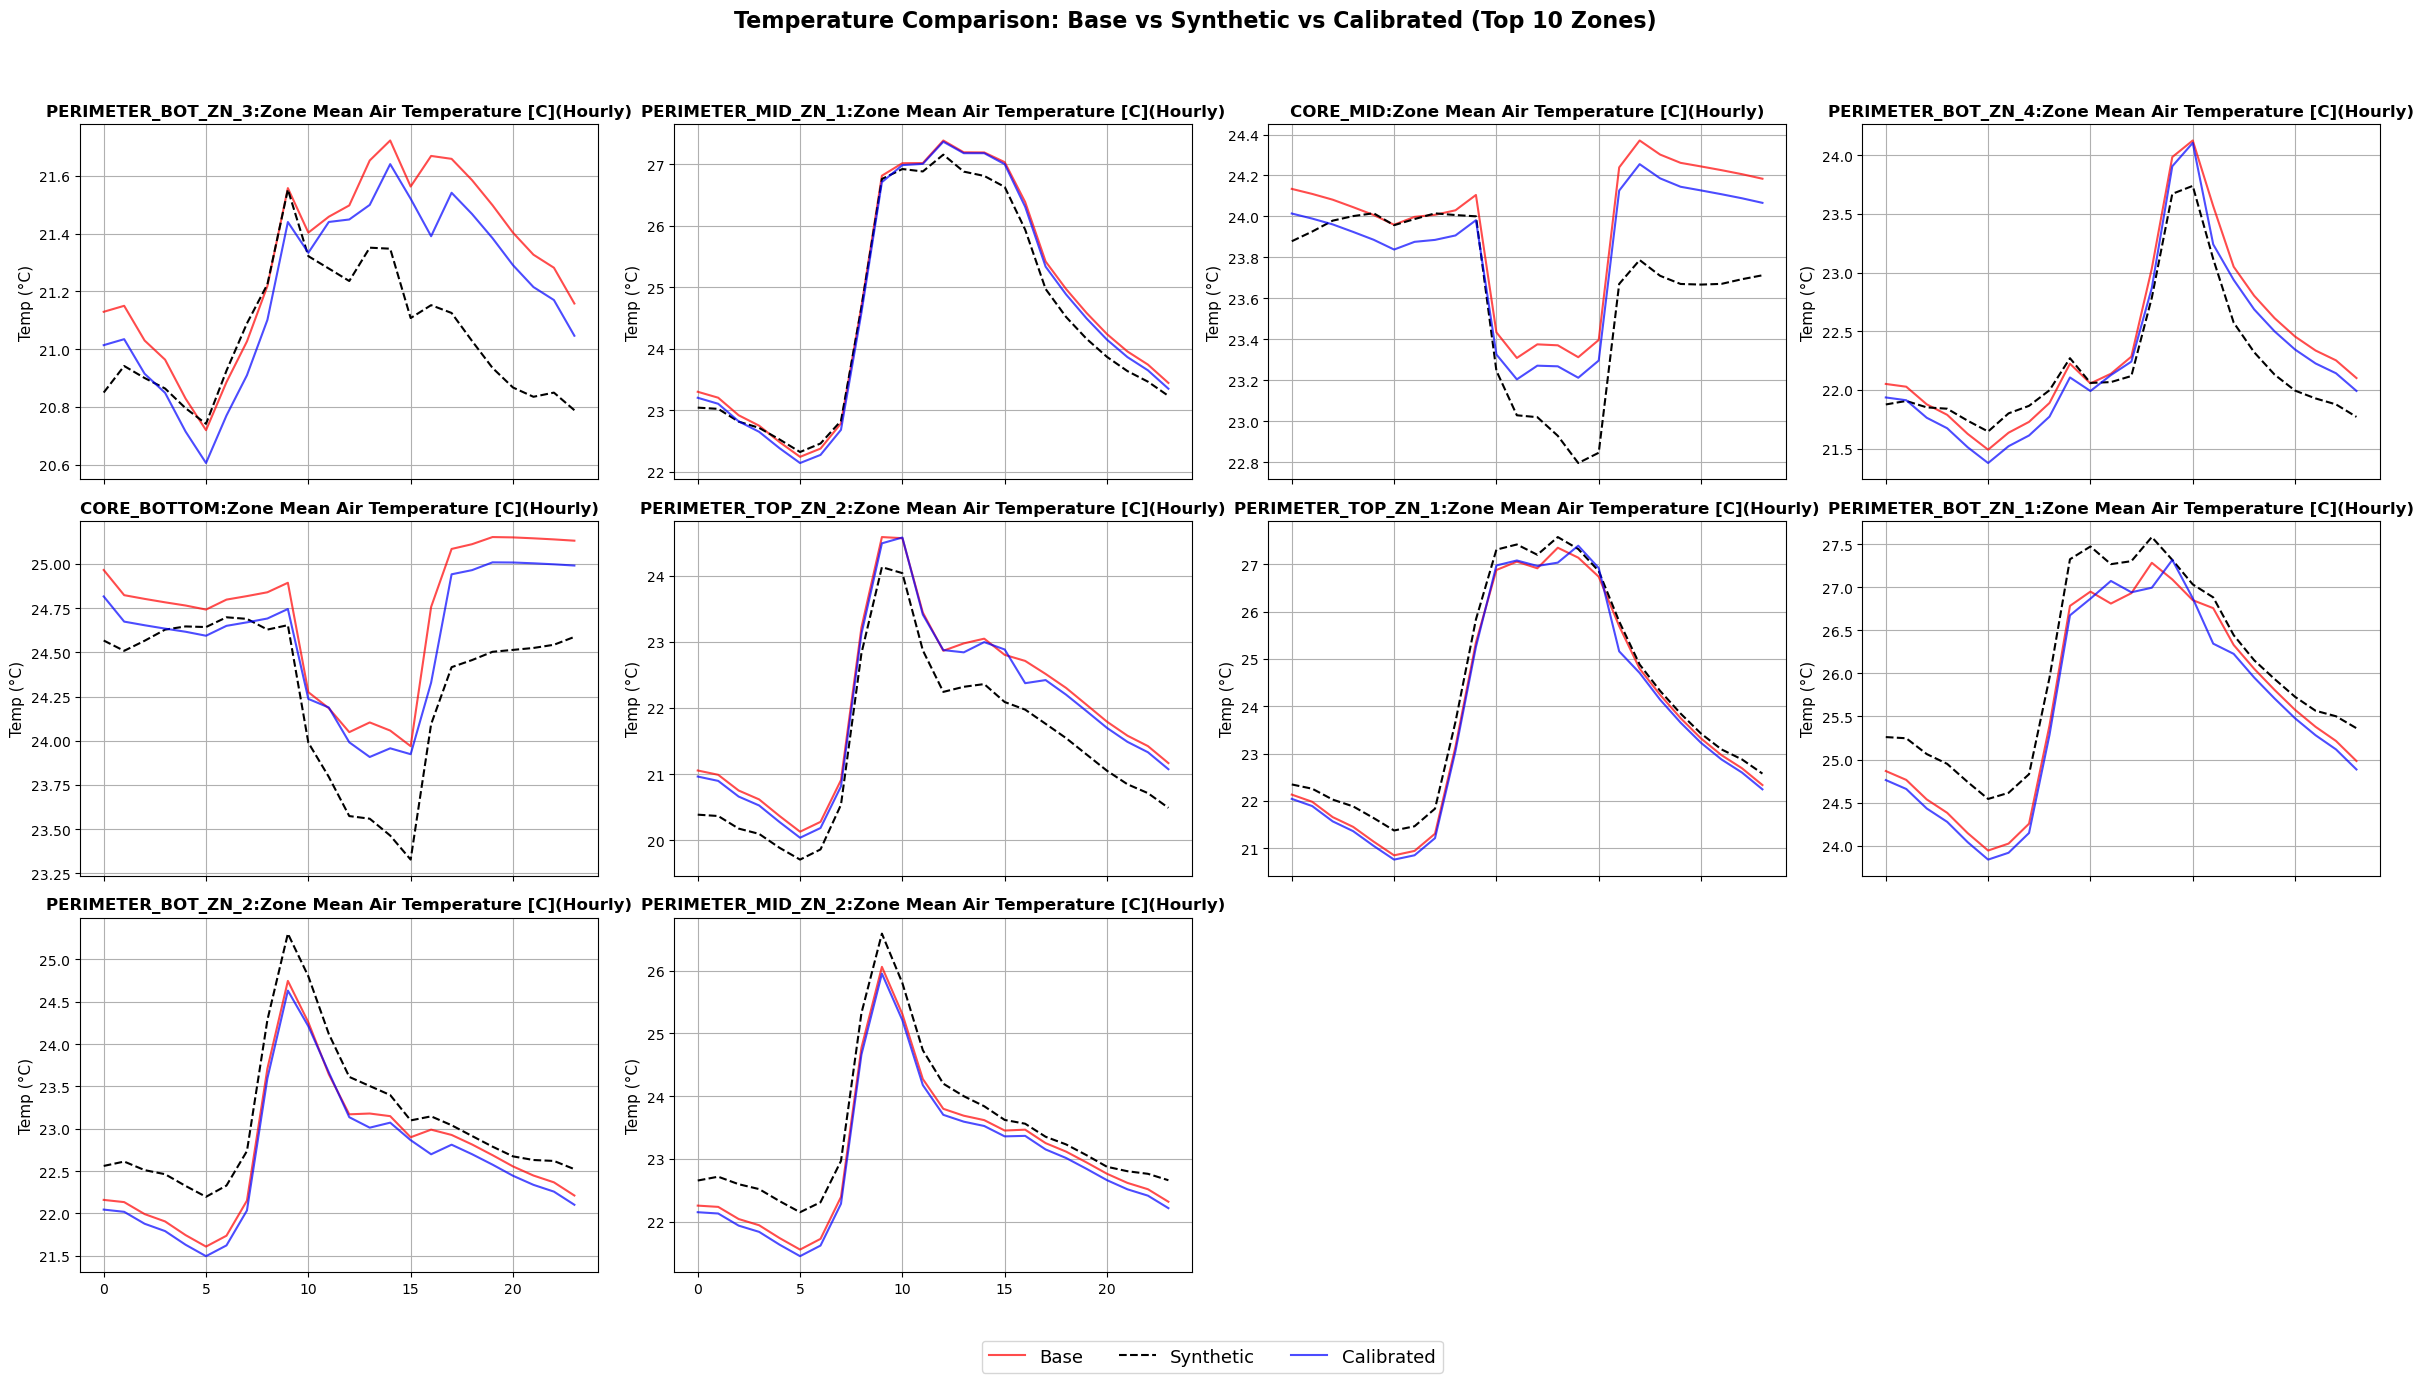

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# File paths (adjust if needed)
# -----------------------------
synthetic_csv   = "data3.csv"                          
base_csv        = "model.csv"    
calibrated_csv  = "calibration_10_newdata/eplusout.csv"

# -----------------------------
# Load all CSVs
# -----------------------------
df_synth = pd.read_csv(synthetic_csv)
df_base  = pd.read_csv(base_csv)
df_cal   = pd.read_csv(calibrated_csv)

# Clean Date/Time
for df in [df_synth, df_base, df_cal]:
    df["Date/Time"] = df["Date/Time"].astype(str).str.strip()

# -----------------------------
# Top 10 zones of interest
# -----------------------------
TOP10_ZONES = [
    "PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "CORE_MID:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_4:Zone Mean Air Temperature [C](Hourly)",
    "CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_2:Zone Mean Air Temperature [C](Hourly)"
]

# Keep only available zones
zone_cols = [z for z in TOP10_ZONES if z in df_base.columns]

# -----------------------------
# Merge base, synth, and calibrated on Date/Time
# -----------------------------
df_merged = df_base[["Date/Time"] + zone_cols].merge(
    df_synth[["Date/Time"] + zone_cols], on="Date/Time", suffixes=("_base", "_synth")
).merge(
    df_cal[["Date/Time"] + zone_cols], on="Date/Time"
)

# Rename calibrated columns
rename_map = {c: c + "_cal" for c in zone_cols}
df_merged.rename(columns=rename_map, inplace=True)

# -----------------------------
# Plotting only the top 10 zones (3 rows × 4 columns)
# -----------------------------
fig, axes = plt.subplots(3, 4, figsize=(24, 14), sharex=True)  # 3 rows × 4 cols
axes = axes.flatten()

for i, zone in enumerate(zone_cols):
    ax = axes[i]
    ax.plot(df_merged.index, df_merged[f"{zone}_base"], label="Base", color="red", alpha=0.7)
    ax.plot(df_merged.index, df_merged[f"{zone}_synth"], label="Synthetic", color="black", linestyle="--")
    ax.plot(df_merged.index, df_merged[f"{zone}_cal"], label="Calibrated", color="blue", alpha=0.7)
    ax.set_title(zone, fontsize=12, fontweight="bold")
    ax.set_ylabel("Temp (°C)", fontsize=11)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.grid(True)

# Hide unused subplots (12 slots – 10 zones = 2 empty)
for j in range(len(zone_cols), len(axes)):
    fig.delaxes(axes[j])

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=13)

plt.suptitle("Temperature Comparison: Base vs Synthetic vs Calibrated (Top 10 Zones)", 
             fontsize=16, fontweight="bold", y=0.98)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# -----------------------------
# Save and show
# -----------------------------
plt.savefig("temperature_comparison_top10.png", dpi=300, bbox_inches="tight")
plt.show()


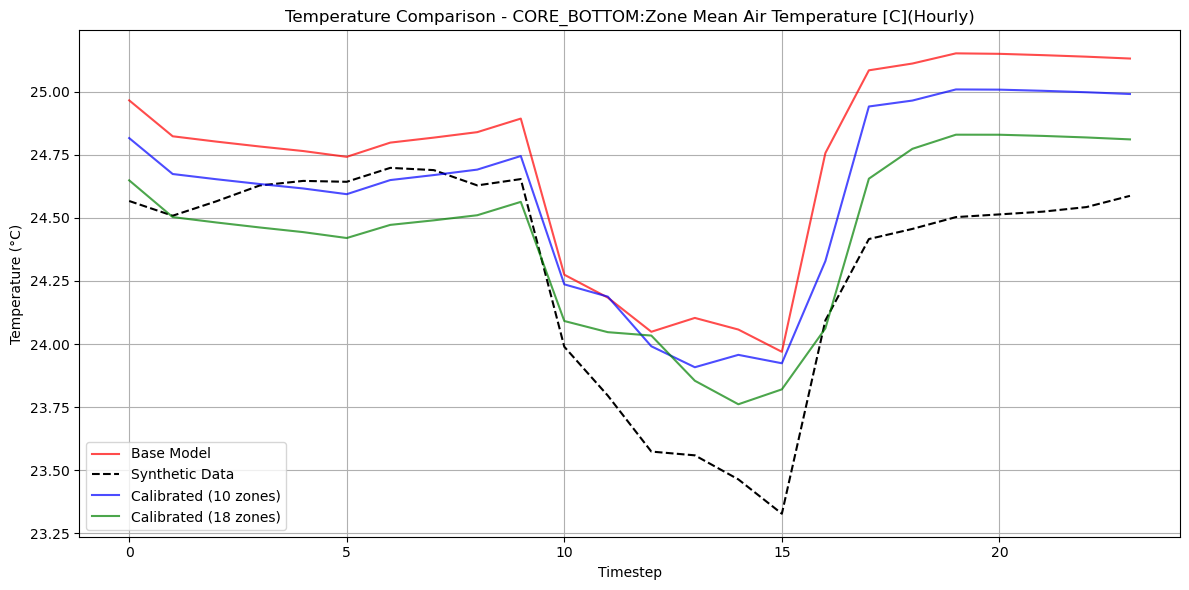

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths (adjust if needed)
synthetic_csv    = "data3.csv"                             # synthetic dataset
base_csv         = "model.csv"                             # base model output
cal_10_csv       = "calibration_10_newdata/eplusout.csv"           # calibrated 10 zones
cal_18_csv       = "calibration_output_newdata/eplusout.csv"           # calibrated 18 zones

# Choose one zone to plot (can change to any of the 18 zones)
zone = "CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)"

# Load all CSVs
df_synth = pd.read_csv(synthetic_csv)
df_base  = pd.read_csv(base_csv)
df_cal10 = pd.read_csv(cal_10_csv)
df_cal18 = pd.read_csv(cal_18_csv)

# Strip spaces in Date/Time for alignment
for df in [df_synth, df_base, df_cal10, df_cal18]:
    df["Date/Time"] = df["Date/Time"].astype(str).str.strip()

# Merge everything on Date/Time
df_plot = (
    df_base[["Date/Time", zone]]
    .merge(df_synth[["Date/Time", zone]], on="Date/Time", suffixes=("_base", "_synth"))
    .merge(df_cal10[["Date/Time", zone]], on="Date/Time")
    .merge(df_cal18[["Date/Time", zone]], on="Date/Time", suffixes=("_cal10", "_cal18"))
)

# Rename clearly
df_plot.rename(columns={zone+"_cal10": f"{zone}_calibrated_10",
                        zone+"_cal18": f"{zone}_calibrated_18"}, inplace=True)

# Convert Date/Time to numeric index for plotting
df_plot["TimeIndex"] = range(len(df_plot))

# Plot
plt.figure(figsize=(12,6))
plt.plot(df_plot["TimeIndex"], df_plot[f"{zone}_base"], label="Base Model", color="red", alpha=0.7)
plt.plot(df_plot["TimeIndex"], df_plot[f"{zone}_synth"], label="Synthetic Data", color="black", linestyle="--")
plt.plot(df_plot["TimeIndex"], df_plot[f"{zone}_calibrated_10"], label="Calibrated (10 zones)", color="blue", alpha=0.7)
plt.plot(df_plot["TimeIndex"], df_plot[f"{zone}_calibrated_18"], label="Calibrated (18 zones)", color="green", alpha=0.7)

plt.title(f"Temperature Comparison - {zone}")
plt.xlabel("Timestep")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
